# 09 — Text Generation: From Logits to Words

**Lecture goal:** turn the raw score table (`logits`) our model produces into an actual next-token choice, repeat that process to generate whole passages, and understand the common decoding strategies (greedy, temperature, top-k) that control *how* that choice gets made.

## The autoregressive generation loop

"Autoregressive" means: the model's own previous outputs become part of its next input. Concretely, generating text is a loop:

1. Feed the current sequence of token IDs into the model.
2. Look at the logits for the **last** position only — that's the model's prediction for "what comes right after everything so far."
3. Turn those logits into a chosen next token ID (several strategies for *how*, covered below).
4. Append that token ID to the sequence.
5. Go back to step 1, and repeat, until we've generated as many new tokens as we want.

Let's rebuild our small model from notebook 08 (untrained — random weights, same as it left off) to generate from.

In [1]:
import torch
import torch.nn as nn
import tiktoken


class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        batch_size, num_tokens, d_in = x.shape
        queries = self.W_query(x).view(batch_size, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys = self.W_key(x).view(batch_size, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values = self.W_value(x).view(batch_size, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        attention_scores = queries @ keys.transpose(2, 3)
        attention_scores.masked_fill_(self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
        attention_weights = torch.softmax(attention_scores / self.head_dim ** 0.5, dim=-1)
        attention_weights = self.dropout(attention_weights)
        context_vectors = (attention_weights @ values).transpose(1, 2)
        context_vectors = context_vectors.contiguous().view(batch_size, num_tokens, self.d_out)
        return self.out_proj(context_vectors)


class LayerNorm(nn.Module):
    def __init__(self, embedding_dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(embedding_dim))
        self.shift = nn.Parameter(torch.zeros(embedding_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        normalized = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * normalized + self.shift


class FeedForward(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(embedding_dim, 4 * embedding_dim), nn.GELU(), nn.Linear(4 * embedding_dim, embedding_dim)
        )

    def forward(self, x):
        return self.layers(x)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.attention = MultiHeadAttention(
            d_in=cfg["embedding_dim"], d_out=cfg["embedding_dim"], context_length=cfg["context_length"],
            dropout=cfg["dropout_rate"], num_heads=cfg["num_heads"], qkv_bias=cfg["qkv_bias"],
        )
        self.feed_forward = FeedForward(cfg["embedding_dim"])
        self.norm1 = LayerNorm(cfg["embedding_dim"])
        self.norm2 = LayerNorm(cfg["embedding_dim"])
        self.dropout = nn.Dropout(cfg["dropout_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.attention(x)
        x = self.dropout(x)
        x = x + shortcut
        shortcut = x
        x = self.norm2(x)
        x = self.feed_forward(x)
        x = self.dropout(x)
        x = x + shortcut
        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.token_embedding = nn.Embedding(cfg["vocab_size"], cfg["embedding_dim"])
        self.position_embedding = nn.Embedding(cfg["context_length"], cfg["embedding_dim"])
        self.dropout = nn.Dropout(cfg["dropout_rate"])
        self.transformer_blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["num_layers"])])
        self.final_norm = LayerNorm(cfg["embedding_dim"])
        self.out_head = nn.Linear(cfg["embedding_dim"], cfg["vocab_size"], bias=False)

    def forward(self, token_ids):
        batch_size, num_tokens = token_ids.shape
        token_embeds = self.token_embedding(token_ids)
        positions = torch.arange(num_tokens, device=token_ids.device)
        pos_embeds = self.position_embedding(positions)
        x = self.dropout(token_embeds + pos_embeds)
        x = self.transformer_blocks(x)
        x = self.final_norm(x)
        return self.out_head(x)


GPT_CONFIG_SMALL = {
    "vocab_size": 50257,
    "context_length": 128,
    "embedding_dim": 256,
    "num_heads": 4,
    "num_layers": 4,
    "dropout_rate": 0.1,
    "qkv_bias": False,
}

tokenizer = tiktoken.get_encoding("gpt2")

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_SMALL)
model.eval()  # disables dropout - we want deterministic, non-regularized behavior for generation
print("Model built. Total parameters:", sum(p.numel() for p in model.parameters()))

Model built. Total parameters: 28920832


(`model.eval()` switches off training-only behaviors like dropout — during generation we always want the model's true, best-effort output, not a randomly perturbed version of it. There's a matching `model.train()` we'll use to switch dropout back on for the actual training loop in notebook 10.)

## Strategy 1: Greedy decoding — always pick the single most likely token

The simplest possible strategy: at each step, take the `argmax` of the probability distribution — the single highest-scoring token — with no randomness at all. Same input always produces exactly the same output.

In [2]:
def generate_text_greedy(model, token_ids, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        # The model was only built to handle up to `context_size` positions (recall the
        # positional embedding table in notebook 04/08 has exactly that many rows) — so if
        # our sequence has grown longer than that, only keep the most recent `context_size` tokens.
        idx_condition = token_ids[:, -context_size:]

        with torch.no_grad():  # we're not training, so skip building the autograd graph - saves time/memory
            logits = model(idx_condition)

        # Only the last position's logits matter - that's the prediction for "what comes next."
        last_logits = logits[:, -1, :]
        probabilities = torch.softmax(last_logits, dim=-1)

        next_token_id = torch.argmax(probabilities, dim=-1, keepdim=True)
        token_ids = torch.cat([token_ids, next_token_id], dim=1)

    return token_ids

In [3]:
start_text = "Every effort moves you"
encoded = tokenizer.encode(start_text)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # add a batch dimension: (num_tokens,) -> (1, num_tokens)
print("Encoded input shape:", encoded_tensor.shape)

output_ids = generate_text_greedy(
    model, encoded_tensor, max_new_tokens=10, context_size=GPT_CONFIG_SMALL["context_length"]
)
print("Output token IDs:", output_ids)
print("Decoded text:", repr(tokenizer.decode(output_ids.squeeze(0).tolist())))

Encoded input shape: torch.Size([1, 4])
Output token IDs: tensor([[ 6109,  3626,  6100,   345, 35573, 38914, 47316, 29559, 22162,  5409,
         12767, 46540, 32121, 47133]])
Decoded text: 'Every effort moves you mosquitoes popcorn appeaseAMES Lucy decide Pittsburgh Stainless utilizationRegistration'


That output is gibberish — and it's *supposed* to be. Every weight in this model is still the random number it was initialized with; nothing has been trained yet. The mechanism is exactly right, though: this is precisely the loop that produces fluent text once the underlying weights actually encode something about language, which is exactly what notebook 10 (training) will do. For now, we're validating the *plumbing*, not the *quality*.

## Strategy 2: Temperature scaling — controlling how "confident" sampling is

Greedy decoding is deterministic and, in practice, tends to produce dull, repetitive text (always picking the "safest" next word). We'd rather *sample* from the probability distribution instead of always taking the top choice — but we also want control over how bold or conservative that sampling is. That control knob is called **temperature**.

Before applying softmax, divide the logits by a temperature value `T`:

```
probabilities = softmax(logits / T)
```

- `T < 1` makes the distribution **sharper/more peaked** — the model's current favorite becomes even more dominant, sampling behaves closer to greedy.
- `T = 1` leaves the distribution unchanged — plain softmax.
- `T > 1` makes the distribution **flatter/more uniform** — weaker candidates get a real chance of being picked, increasing diversity (and risk of nonsense) in the output.

Let's see this effect directly on a small toy set of logits.

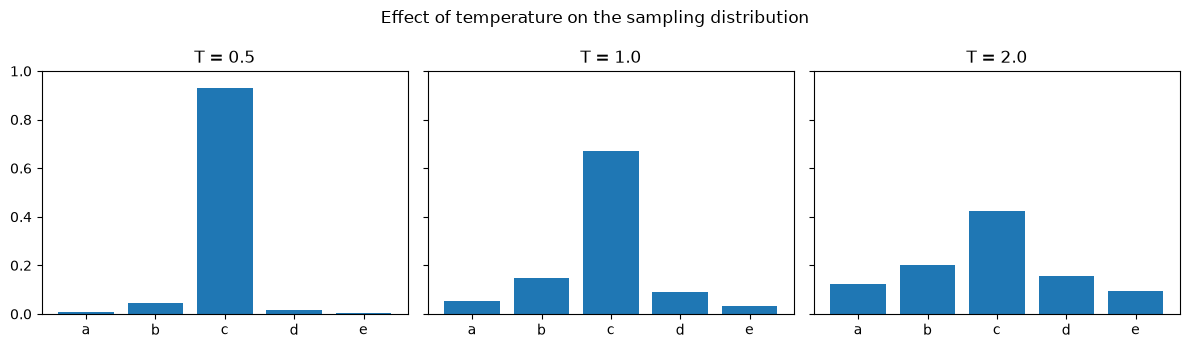

In [4]:
import matplotlib.pyplot as plt

toy_vocab = ["a", "b", "c", "d", "e"]
toy_logits = torch.tensor([1.0, 2.0, 3.5, 1.5, 0.5])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, temperature in zip(axes, [0.5, 1.0, 2.0]):
    probs = torch.softmax(toy_logits / temperature, dim=-1)
    ax.bar(toy_vocab, probs)
    ax.set_title(f"T = {temperature}")
    ax.set_ylim(0, 1)
plt.suptitle("Effect of temperature on the sampling distribution")
plt.tight_layout()
plt.show()

At `T = 0.5`, token `"c"` (the highest logit) dominates even more than before; at `T = 2.0`, the distribution flattens out and the "worse" tokens become far more likely to be picked. This is why generation APIs (including production LLM APIs) commonly expose a `temperature` parameter — it's exactly this knob.

## Strategy 3: Top-k sampling — restricting the candidate pool

Temperature alone has a downside: even at low temperatures, *every* token in the vocabulary still has some nonzero probability of being sampled — including wildly inappropriate ones far down the ranking. **Top-k sampling** fixes this by first restricting the candidates to only the `k` highest-scoring tokens (setting every other token's logit to `-inf`, so it gets exactly zero probability after softmax), and only *then* sampling with temperature among those `k`.

In [5]:
def apply_top_k(logits, k):
    top_k_values, _ = torch.topk(logits, k)
    min_value_to_keep = top_k_values[:, -1]
    return torch.where(
        logits < min_value_to_keep.unsqueeze(-1),
        torch.tensor(-torch.inf, device=logits.device),
        logits,
    )


masked_toy_logits = apply_top_k(toy_logits.unsqueeze(0), k=3)
print("Original logits:  ", toy_logits)
print("Top-3 masked logits:", masked_toy_logits)

Original logits:   tensor([1.0000, 2.0000, 3.5000, 1.5000, 0.5000])
Top-3 masked logits: tensor([[  -inf, 2.0000, 3.5000, 1.5000,   -inf]])


The two lowest-scoring tokens got set to `-inf`, guaranteeing they receive exactly 0 probability after softmax, while the top 3 keep their original relative scores (still shaped further by whatever temperature we then apply).

## Putting it together: a full `generate` function

Combine top-k filtering, temperature-scaled softmax, and **sampling** (via `torch.multinomial`, which draws a random index according to a given probability distribution — unlike `argmax`, which always deterministically takes the single highest one).

In [6]:
def generate(model, token_ids, max_new_tokens, context_size, temperature=1.0, top_k=None):
    for _ in range(max_new_tokens):
        idx_condition = token_ids[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_condition)
        last_logits = logits[:, -1, :]

        if top_k is not None:
            last_logits = apply_top_k(last_logits, top_k)

        if temperature > 0.0:
            probabilities = torch.softmax(last_logits / temperature, dim=-1)
            next_token_id = torch.multinomial(probabilities, num_samples=1)
        else:
            # temperature == 0 is a shorthand for "just be greedy"
            next_token_id = torch.argmax(last_logits, dim=-1, keepdim=True)

        token_ids = torch.cat([token_ids, next_token_id], dim=1)

    return token_ids

In [7]:
torch.manual_seed(123)
output_ids = generate(
    model, encoded_tensor, max_new_tokens=10,
    context_size=GPT_CONFIG_SMALL["context_length"], temperature=1.4, top_k=25,
)
print("Decoded text:", repr(tokenizer.decode(output_ids.squeeze(0).tolist())))

Decoded text: 'Every effort moves youfore breourning pies compliments Miy YouPauseumed Collective'


Still gibberish (again — untrained weights!), but now sampled with controllable randomness instead of pure greedy repetition. This exact `generate` function — unchanged — is what we'll use in notebook 10 to check the model's progress *during* training, and again in notebook 11 with real pretrained GPT-2 weights, where the output will suddenly become fluent English.

## Recap

- Generation is a loop: feed in the sequence so far, look at the **last position's** logits only, choose a next token, append it, repeat.
- **Greedy decoding** (`argmax`) is deterministic and simple but tends to be repetitive.
- **Temperature** reshapes the probability distribution before sampling: low temperature → more confident/deterministic, high temperature → more random/diverse.
- **Top-k sampling** restricts candidates to the `k` best options before sampling, avoiding truly bad tokens while still allowing controlled randomness.
- None of this makes an *untrained* model's output meaningful — decoding strategy only controls *how* a choice is made among the model's predictions; it can't fix predictions that haven't been trained yet.

### What's next

Time to fix that: in notebook 10, we'll define a loss function, build the training loop, and actually train `GPT_CONFIG_SMALL` on `the-verdict.txt` — watching the exact same `generate` function above produce increasingly coherent text as training progresses.